# MetroGNN — Training Template

**Architecture:** Full Metropolitan Graph → GraphSAGE Encoder → Subgraph Pooling → Multi-task Heads → Structured JSON → LLM Layer

```
┌────────────────────────────┐
│ Full Metropolitan Graph    │
│ (OSM + GTFS + SIRI + etc.) │
└────────────┬───────────────┘
             ↓
┌────────────────────────────┐
│ Node / Edge Feature Builder│
└────────────┬───────────────┘
             ↓
┌────────────────────────────┐
│  GraphSAGE Encoder (×3)    │
└────────────┬───────────────┘
             ↓  node embeddings
┌────────────────────────────┐
│  Subgraph Pooling (mean)   │
└────────────┬───────────────┘
             ↓  area embedding vector
   ┌─────────┬─────────┬─────────┬─────────┬─────────┐
   ↓         ↓         ↓         ↓         ↓         ↓
Access.  Connect.  Transit   Bike    Network   Area
  Reg.     Reg.     Reg.     Reg.    Role Cls  Type Cls
             ↓
┌────────────────────────────┐
│  Structured JSON Output    │
└────────────┬───────────────┘
             ↓
┌────────────────────────────┐
│  LLM Explanation Layer     │
└────────────────────────────┘
```

---
**Standalone — no dependency on the Map Chat backend.**

---
## 0. Setup & Config

In [1]:
import osmnx as ox
from pathlib import Path

GRAPH_PATH = Path("data/osm_road.graphml")
GRAPH_PATH.parent.mkdir(exist_ok=True)

if GRAPH_PATH.exists():
    print("Loading graph from file...")
    G = ox.load_graphml(GRAPH_PATH)
else:
    print("Downloading OSM graph...")
    G = ox.graph_from_place("Tel Aviv-Yafo, Israel", network_type="drive")
    # Do NOT project — keep WGS84 so GTFS BallTree/haversine queries work.
    # If you need metric distances later, use ox.project_graph() locally
    # without re-saving, or use G.graph["crs"] + pyproj.
    ox.save_graphml(G, GRAPH_PATH)
    print("Saved to", GRAPH_PATH)

print(f"Nodes: {G.number_of_nodes():,}  Edges: {G.number_of_edges():,}")
print(f"CRS: {G.graph.get('crs', 'WGS84/unprojected')}")


Loading graph from file...


Nodes: 6,498  Edges: 12,465
CRS: epsg:4326


In [2]:
SHAPE_DIR = Path("data/shapefiles")

if (SHAPE_DIR / "nodes.shp").exists() and (SHAPE_DIR / "edges.shp").exists():
    print("Shapefiles already exist, skipping.")
else:
    SHAPE_DIR.mkdir(parents=True, exist_ok=True)
    nodes, edges = ox.graph_to_gdfs(G)
    nodes.to_file(SHAPE_DIR / "nodes.shp")
    edges.to_file(SHAPE_DIR / "edges.shp")
    print(f"Shapefiles saved to {SHAPE_DIR}/")
    print(f"  nodes: {len(nodes):,}  edges: {len(edges):,}")

Shapefiles already exist, skipping.


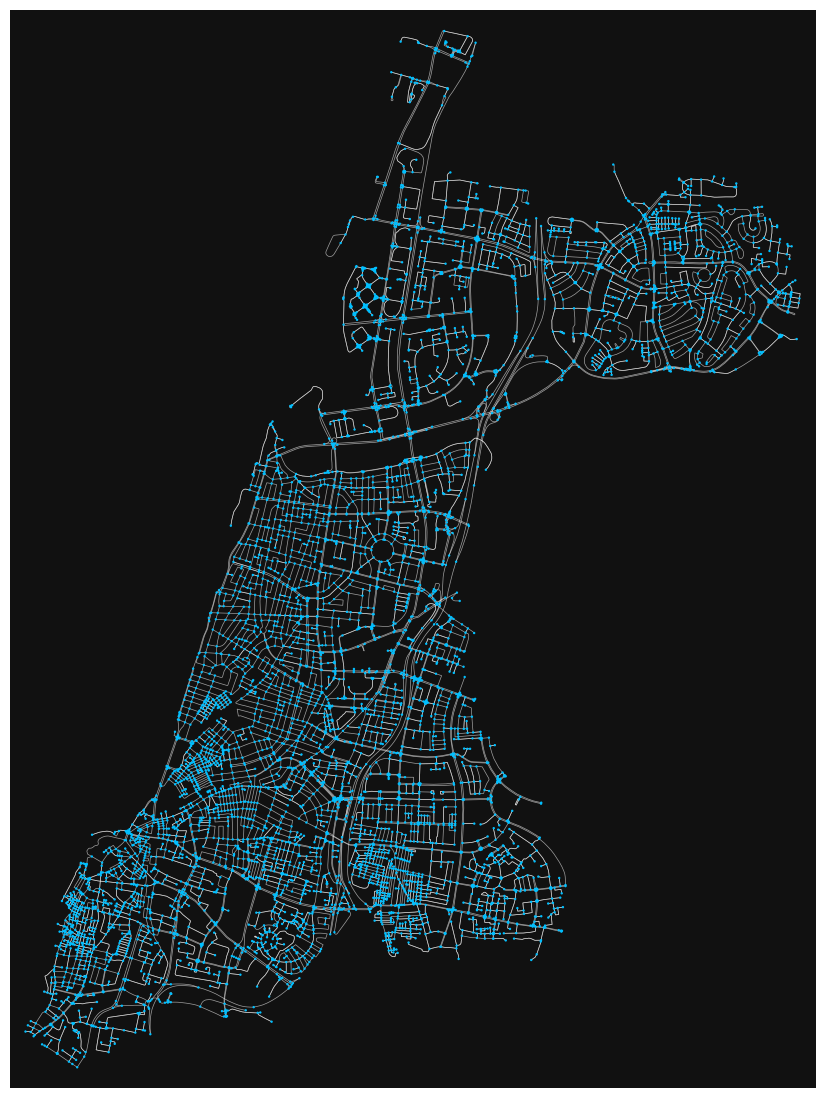

In [3]:
fig, ax = ox.plot_graph(
    G,
    figsize=(14, 14),
    bgcolor="#111111",
    node_color="#00bfff",
    node_size=3,
    edge_color="#ffffff",
    edge_linewidth=0.5,
    edge_alpha=0.6,
    show=True,
    close=False,
)
ax.set_title("Tel Aviv-Yafo — Road Network", color="white", fontsize=16, pad=12)
fig.tight_layout()

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.neighbors import BallTree

FEATURES_PATH = Path("data/node_features.npz")

FEATURE_NAMES = [
    "degree",
    "road_major_count",
    "road_residential_count",
    "road_service_count",
    "bus_stop_count",
    "light_rail_stop_count",
    "train_stop_count",
    "unique_gtfs_routes_count",
]

if FEATURES_PATH.exists():
    saved = np.load(FEATURES_PATH, allow_pickle=True)
    X        = saved["X"]
    node_ids = list(saved["node_ids"])
    print(f"Loaded from cache: {X.shape[0]:,} nodes × {X.shape[1]} features")
else:
    MAJOR_TYPES       = {"motorway", "trunk", "primary", "secondary", "tertiary"}
    RESIDENTIAL_TYPES = {"residential", "living_street", "unclassified"}
    SERVICE_TYPES     = {"service"}

    def _highway(val):
        if isinstance(val, list): val = val[0]
        return str(val) if val else "other"

    def _first_edge(G, u, v):
        edata = G.get_edge_data(u, v)
        return list(edata.values())[0] if edata else {}

    GTFS_DIR = Path("data/israel-public-transportation")
    stops_raw  = pd.read_csv(GTFS_DIR / "stops.txt",      usecols=["stop_id", "stop_lat", "stop_lon"])
    routes_raw = pd.read_csv(GTFS_DIR / "routes.txt",     usecols=["route_id", "route_type"])
    trips_raw  = pd.read_csv(GTFS_DIR / "trips.txt",      usecols=["route_id", "trip_id"])
    st_raw     = pd.read_csv(GTFS_DIR / "stop_times.txt", usecols=["trip_id", "stop_id"])

    trip2route = trips_raw.set_index("trip_id")["route_id"].to_dict()
    route2type = routes_raw.set_index("route_id")["route_type"].to_dict()
    stop_routes = (
        st_raw.assign(route_id=st_raw["trip_id"].map(trip2route))
              .groupby("stop_id")["route_id"].agg(set).reset_index()
    )
    stop_routes["route_types"] = stop_routes["route_id"].apply(
        lambda rs: {route2type.get(r) for r in rs if r in route2type}
    )
    stop_meta = stops_raw.merge(stop_routes, on="stop_id", how="left")
    stop_meta["route_types"] = stop_meta["route_types"].apply(lambda x: x if isinstance(x, set) else set())
    stop_meta["route_id"]    = stop_meta["route_id"].apply(lambda x: x if isinstance(x, set) else set())
    print(f"GTFS loaded: {len(stop_meta):,} stops")

    _nd0 = G.nodes[list(G.nodes)[0]]
    _lat0, _lon0 = _nd0.get("y", 0.0), _nd0.get("x", 0.0)
    assert 29 < _lat0 < 34 and 34 < _lon0 < 36, (
        f"Projected coords detected (lat={_lat0:.1f}). "
        "Delete data/osm_road.graphml and rerun cell 0."
    )
    print(f"Coord check OK  lat={_lat0:.5f}  lon={_lon0:.5f}")

    RADIUS_M = 400   # GTFS stops within this radius count toward each OSM node
    stop_coords_rad = np.deg2rad(stop_meta[["stop_lat", "stop_lon"]].values)
    stop_tree = BallTree(stop_coords_rad, metric="haversine")

    Gu = G.to_undirected()
    node_ids = list(G.nodes)
    rows = []

    for nid in node_ids:
        nd  = G.nodes[nid]
        lat = nd.get("y", 0.0)
        lon = nd.get("x", 0.0)
        deg = Gu.degree(nid)

        major_cnt = res_cnt = svc_cnt = 0
        for nb in Gu.neighbors(nid):
            hw = _highway(_first_edge(Gu, nid, nb).get("highway", "other"))
            if hw in MAJOR_TYPES:         major_cnt += 1
            elif hw in RESIDENTIAL_TYPES: res_cnt   += 1
            elif hw in SERVICE_TYPES:     svc_cnt   += 1

        pt  = np.deg2rad([[lat, lon]])
        idx = stop_tree.query_radius(pt, r=RADIUS_M / 6_371_000)[0]
        nearby = stop_meta.iloc[idx]

        bus_cnt   = int(nearby["route_types"].apply(lambda s: 3 in s).sum())
        lrt_cnt   = int(nearby["route_types"].apply(lambda s: 0 in s).sum())
        train_cnt = int(nearby["route_types"].apply(lambda s: 2 in s).sum())
        all_routes = set().union(*nearby["route_id"]) if len(nearby) else set()
        route_cnt  = len(all_routes)

        rows.append([deg, major_cnt, res_cnt, svc_cnt,
                     bus_cnt, lrt_cnt, train_cnt, route_cnt])

    X = np.array(rows, dtype=np.float32)
    np.savez(FEATURES_PATH, X=X, node_ids=np.array(node_ids))
    print(f"Saved to {FEATURES_PATH}")

print(f"\nFeature matrix: {X.shape[0]:,} nodes × {X.shape[1]} features")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {name:30s}  mean={X[:,i].mean():.2f}  max={X[:,i].max():.0f}")


Loaded from cache: 6,498 nodes × 8 features

Feature matrix: 6,498 nodes × 8 features
  degree                          mean=2.93  max=7
  road_major_count                mean=0.97  max=6
  road_residential_count          mean=1.81  max=5
  road_service_count              mean=0.00  max=0
  bus_stop_count                  mean=11.74  max=59
  light_rail_stop_count           mean=0.34  max=4
  train_stop_count                mean=0.06  max=1
  unique_gtfs_routes_count        mean=99.41  max=1119


In [5]:
# pip install torch torchvision tqdm
# torch_geometric: https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import SAGEConv, BatchNorm, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import subgraph as pyg_subgraph
from sklearn.neighbors import BallTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import json

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw): return x

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

CFG = dict(
    hidden_dim   = 64,
    dropout      = 0.5,       # raised from 0.3 — reduces overfitting
    lr           = 1e-3,
    weight_decay = 5e-4,      # raised from 1e-4 — L2 regularisation
    epochs       = 60,
    batch_size   = 64,
    subgraph_r_m = 250,
    data_dir     = Path('data'),
    out_dir      = Path('outputs'),
)
CFG['data_dir'].mkdir(exist_ok=True)
CFG['out_dir'].mkdir(exist_ok=True)

CONN_LABELS = ['low', 'medium', 'high']
PT_LABELS   = ['poor', 'moderate', 'rich']
ROLE_LABELS = ['isolated', 'residential', 'transit_served', 'local_hub', 'metropolitan_hub']

print("Config OK")


C:\Users\gabri\Dropbox\map-chat\map-chat\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Config OK


---
## 1. Dataset Construction — 250m Subgraphs

For every OSM road-intersection node:
1. Find all nodes within a **250m spatial radius**
2. Extract the induced subgraph (nodes + edges)
3. Compute **evidence** by aggregating node features over the subgraph
4. Derive **labels** from evidence using percentile-calibrated thresholds
5. Store as one PyG `Data` object → one training sample

| Label | Classes | Derived from |
|---|---|---|
| `connectivity_level` | low / medium / high | major intersections in 250m subgraph |
| `public_transport_level` | poor / moderate / rich | total bus stops in 250m subgraph |
| `network_role` | isolated / residential / transit_served / local_hub / metropolitan_hub | composite score |


In [6]:
from sklearn.preprocessing import StandardScaler

DATASET_PATH = CFG['data_dir'] / 'subgraph_dataset.pt'

# ── Feature preprocessing ──────────────────────────────────────────────────────
# Drop col 3 (road_service_count — always 0), log1p skewed routes col, StandardScaler
FEAT_COLS = [0, 1, 2, 4, 5, 6, 7]           # 7 features (drop col 3 = road_service_count)
X_raw  = X[:, FEAT_COLS]
X_proc = X_raw.copy()
X_proc[:, -1] = np.log1p(X_proc[:, -1])     # log1p on unique_gtfs_routes_count
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_proc).astype(np.float32)

X_raw_tensor  = torch.tensor(X,      dtype=torch.float)   # 8 cols — evidence only
X_norm_tensor = torch.tensor(X_norm, dtype=torch.float)   # 7 cols normalized — GNN input
IN_DIM = X_norm_tensor.shape[1]   # 7
print(f"IN_DIM={IN_DIM}  (dropped road_service_count, log1p on routes, StandardScaler)")

# ── Spatial index + global edge_index ─────────────────────────────────────────
id2idx = {nid: i for i, nid in enumerate(node_ids)}
src_list, dst_list = [], []
for u, v in G.edges():
    if u in id2idx and v in id2idx:
        src_list.append(id2idx[u])
        dst_list.append(id2idx[v])
edge_index_global = torch.tensor([src_list, dst_list], dtype=torch.long)
N_TOTAL = len(node_ids)

node_coords_rad = np.deg2rad([[G.nodes[nid]['y'], G.nodes[nid]['x']] for nid in node_ids])
node_tree = BallTree(node_coords_rad, metric='haversine')
node_lats = np.array([G.nodes[nid]['y'] for nid in node_ids])

print(f"Graph: {N_TOTAL:,} nodes  {edge_index_global.shape[1]:,} edges")

if DATASET_PATH.exists():
    dataset = torch.load(DATASET_PATH, weights_only=False)
    print(f"Loaded from cache: {len(dataset):,} subgraphs")
else:
    R_RAD = CFG['subgraph_r_m'] / 6_371_000

    # Pass 1: evidence using raw X (8 cols)
    raw = []
    for ci in tqdm(range(N_TOTAL), desc="Evidence pass"):
        local_np  = node_tree.query_radius(node_coords_rad[ci:ci+1], r=R_RAD)[0]
        local_idx = torch.tensor(local_np, dtype=torch.long)
        sub_ei, _ = pyg_subgraph(local_idx, edge_index_global,
                                  relabel_nodes=True, num_nodes=N_TOTAL)
        sub_x_raw  = X_raw_tensor[local_idx]   # 8 cols — evidence
        sub_x_norm = X_norm_tensor[local_idx]  # 7 cols — GNN
        # Raw X cols: 0=deg,1=major,2=res,3=svc,4=bus,5=lrt,6=train,7=routes
        raw.append(dict(
            local_idx    = local_idx,
            sub_ei       = sub_ei,
            sub_x_norm   = sub_x_norm,
            major_inters = int((sub_x_raw[:, 1] > 0).sum()),
            bus_cnt      = int(sub_x_raw[:, 4].sum()),
            lrt_cnt      = int(sub_x_raw[:, 5].sum()),
            train_cnt    = int(sub_x_raw[:, 6].sum()),
            routes_cnt   = int(sub_x_raw[:, 7].sum()),
        ))

    major_arr = np.array([d['major_inters'] for d in raw], dtype=float)
    bus_arr   = np.array([d['bus_cnt']       for d in raw], dtype=float)
    tt_arr    = bus_arr + np.array([d['lrt_cnt'] + d['train_cnt'] for d in raw])

    conn_th = [np.percentile(major_arr, 33), np.percentile(major_arr, 66)]
    pt_th   = [np.percentile(bus_arr,   33), np.percentile(bus_arr,   66)]
    composite = (0.4 * major_arr / (major_arr.max() + 1e-6)
               + 0.6 * tt_arr    / (tt_arr.max()    + 1e-6))
    role_th = [np.percentile(composite, p) for p in [20, 40, 60, 80]]

    print(f"\nLabel thresholds:")
    print(f"  connectivity  [{conn_th[0]:.1f}, {conn_th[1]:.1f}]")
    print(f"  public_transp [{pt_th[0]:.1f}, {pt_th[1]:.1f}]")
    print(f"  role composite percentiles [20,40,60,80]")

    # Pass 2: assign labels; store normalized features in Data.x
    dataset = []
    for i, d in enumerate(raw):
        mi = d['major_inters']
        bc = d['bus_cnt']
        tt = bc + d['lrt_cnt'] + d['train_cnt']

        y_conn = 2 if mi >= conn_th[1] else (1 if mi >= conn_th[0] else 0)
        y_pt   = 2 if bc >= pt_th[1]   else (1 if bc >= pt_th[0]   else 0)
        comp   = 0.4 * (mi / (major_arr.max() + 1e-6)) + 0.6 * (tt / (tt_arr.max() + 1e-6))
        y_role = int(sum(comp >= t for t in role_th))

        dataset.append(Data(
            x          = d['sub_x_norm'],   # normalized 7-col features → GNN
            edge_index = d['sub_ei'],
            y_conn     = torch.tensor(y_conn, dtype=torch.long),
            y_pt       = torch.tensor(y_pt,   dtype=torch.long),
            y_role     = torch.tensor(y_role, dtype=torch.long),
            center_idx = torch.tensor(i,      dtype=torch.long),
            center_lat = torch.tensor(node_lats[i], dtype=torch.float),
            evidence   = torch.tensor(
                [mi, bc, d['lrt_cnt'], d['train_cnt'], d['routes_cnt']], dtype=torch.float),
        ))

    torch.save(dataset, DATASET_PATH)
    print(f"Saved: {len(dataset):,} subgraphs → {DATASET_PATH}")

y_conn_all = [d.y_conn.item() for d in dataset]
y_pt_all   = [d.y_pt.item()   for d in dataset]
y_role_all = [d.y_role.item() for d in dataset]

print(f"\nDataset: {len(dataset):,} samples  |  "
      f"avg nodes/subgraph: {np.mean([d.x.shape[0] for d in dataset]):.1f}")
print("\nLabel distribution:")
for name, labels, all_y in [
    ('connectivity_level',     CONN_LABELS, y_conn_all),
    ('public_transport_level', PT_LABELS,   y_pt_all),
    ('network_role',           ROLE_LABELS, y_role_all),
]:
    counts = Counter(all_y)
    total  = sum(counts.values())
    print(f"  {name}:")
    for i, lbl in enumerate(labels):
        n   = counts.get(i, 0)
        bar = '█' * max(1, int(20 * n / total))
        print(f"    {lbl:18s} {bar:<20} {n:5,}  ({100*n/total:.0f}%)")


IN_DIM=7  (dropped road_service_count, log1p on routes, StandardScaler)
Graph: 6,498 nodes  12,465 edges


Loaded from cache: 6,498 subgraphs

Dataset: 6,498 samples  |  avg nodes/subgraph: 36.3

Label distribution:
  connectivity_level:
    low                █████                1,887  (29%)
    medium             ██████               2,234  (34%)
    high               ███████              2,377  (37%)
  public_transport_level:
    poor               ██████               2,135  (33%)
    moderate           ██████               2,146  (33%)
    rich               ██████               2,217  (34%)
  network_role:
    isolated           ███                  1,296  (20%)
    residential        ████                 1,307  (20%)
    transit_served     ███                  1,296  (20%)
    local_hub          ███                  1,299  (20%)
    metropolitan_hub   ████                 1,300  (20%)


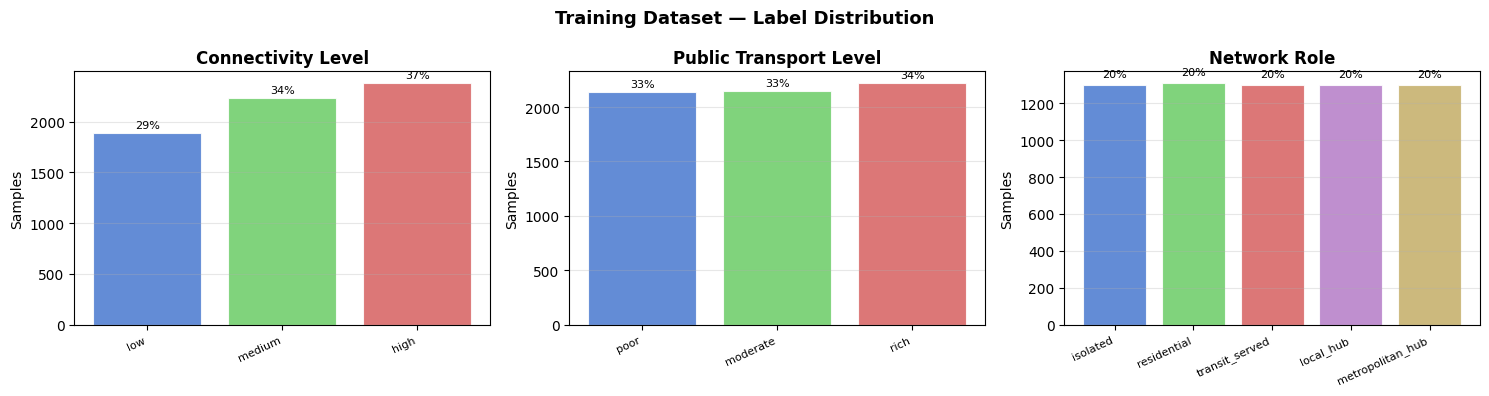

In [7]:
palette = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training Dataset — Label Distribution", fontsize=13, fontweight='bold')

for ax, name, labels, all_y in [
    (axes[0], "Connectivity Level",     CONN_LABELS, y_conn_all),
    (axes[1], "Public Transport Level", PT_LABELS,   y_pt_all),
    (axes[2], "Network Role",           ROLE_LABELS, y_role_all),
]:
    counts = [Counter(all_y).get(i, 0) for i in range(len(labels))]
    total  = sum(counts)
    bars   = ax.bar(range(len(labels)), counts,
                    color=palette[:len(labels)], alpha=0.85,
                    edgecolor='white', linewidth=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel("Samples")
    ax.grid(axis='y', alpha=0.3)
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.005,
                f"{100*n/total:.0f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(CFG['out_dir'] / 'label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 2. Model — MetroGNN

```
Input: 250m subgraph, node features (N_local × 8)
    ↓
SAGEConv → BN → ReLU → Dropout
    ↓
SAGEConv → BN → ReLU → Dropout
    ↓
SAGEConv
    ↓  node embeddings (N_local × hidden_dim)
global_mean_pool
    ↓  subgraph embedding (hidden_dim,)
    ┌──────────────┬──────────────┬──────────────────┐
    ↓              ↓              ↓
connectivity   public_transp   network_role
 low/med/high   poor/mod/rich   5 classes
```


In [8]:
class MetroGNN(torch.nn.Module):
    """
    GraphSAGE encoder → mean pool → 3 classification heads.
    One forward pass processes one 250m subgraph batch.
    """
    def __init__(self, in_dim: int = IN_DIM, hidden_dim: int = 64, dropout: float = 0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(in_dim,     hidden_dim)
        self.bn1   = BatchNorm(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2   = BatchNorm(hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, hidden_dim)
        self.bn3   = BatchNorm(hidden_dim)
        self.head_conn = Linear(hidden_dim, len(CONN_LABELS))   # 3
        self.head_pt   = Linear(hidden_dim, len(PT_LABELS))     # 3
        self.head_role = Linear(hidden_dim, len(ROLE_LABELS))   # 5

    def encode(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = F.relu(self.bn1(self.conv1(x, edge_index)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.bn2(self.conv2(h, edge_index)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.bn3(self.conv3(h, edge_index)))
        return h                                                 # (N_local, hidden_dim)

    def forward(self, x, edge_index, batch):
        g = global_mean_pool(self.encode(x, edge_index), batch)  # (B, hidden_dim)
        return {
            'conn_logits': self.head_conn(g),
            'pt_logits':   self.head_pt(g),
            'role_logits': self.head_role(g),
        }


model = MetroGNN(in_dim=IN_DIM,
                 hidden_dim=CFG['hidden_dim'],
                 dropout=CFG['dropout']).to(DEVICE)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")


MetroGNN(
  (conv1): SAGEConv(7, 64, aggr=mean)
  (bn1): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (bn2): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): SAGEConv(64, 64, aggr=mean)
  (bn3): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (head_conn): Linear(in_features=64, out_features=3, bias=True)
  (head_pt): Linear(in_features=64, out_features=3, bias=True)
  (head_role): Linear(in_features=64, out_features=5, bias=True)
)

Parameters: 18,571


---
## 3. Training

**Loss:** weighted cross-entropy on each head, summed.  
Class weights correct for label imbalance automatically.  
Best checkpoint is restored at the end.


In [9]:
# ── Spatial train / val / test split (70 / 15 / 15) ─────────────────────────
# Split by latitude to avoid leakage between 250m-radius overlapping subgraphs.
# South band (lat < p15) → test | middle band (p15..p30) → val | north (>=p30) → train
lat_p15 = np.percentile(node_lats, 15)
lat_p30 = np.percentile(node_lats, 30)

test_idx  = [i for i, lat in enumerate(node_lats) if lat < lat_p15]
val_idx   = [i for i, lat in enumerate(node_lats) if lat_p15 <= lat < lat_p30]
train_idx = [i for i, lat in enumerate(node_lats) if lat >= lat_p30]

train_data = [dataset[i] for i in train_idx]
val_data   = [dataset[i] for i in val_idx]
test_data  = [dataset[i] for i in test_idx]
print(f"Spatial split:  train={len(train_data):,}  val={len(val_data):,}  test={len(test_data):,}")
print(f"  lat bands:  south <{lat_p15:.4f}° (test) | {lat_p15:.4f}–{lat_p30:.4f}° (val) | >{lat_p30:.4f}° (train)")

BS = CFG['batch_size']
train_loader = DataLoader(train_data, batch_size=BS,   shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_data,   batch_size=BS*2, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=BS*2, shuffle=False, num_workers=0)

# ── Class weights from train set only ─────────────────────────────────────────
def _weights(all_y, n_cls):
    c = Counter(all_y); tot = sum(c.values())
    w = torch.tensor([tot / (n_cls * max(c.get(i, 1), 1)) for i in range(n_cls)], dtype=torch.float)
    return (w / w.mean()).to(DEVICE)

train_conn_y = [dataset[i].y_conn.item() for i in train_idx]
train_pt_y   = [dataset[i].y_pt.item()   for i in train_idx]
train_role_y = [dataset[i].y_role.item() for i in train_idx]

w_conn = _weights(train_conn_y, len(CONN_LABELS))
w_pt   = _weights(train_pt_y,   len(PT_LABELS))
w_role = _weights(train_role_y, len(ROLE_LABELS))

# ── Optimiser + warmup → cosine LR ───────────────────────────────────────────
WARMUP_EPOCHS = 5
optimizer = torch.optim.Adam(model.parameters(),
                             lr=CFG['lr'], weight_decay=CFG['weight_decay'])
warmup_sched = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'] - WARMUP_EPOCHS)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS])

# ── Helpers ───────────────────────────────────────────────────────────────────
def loss_fn(out, batch):
    return (F.cross_entropy(out['conn_logits'], batch.y_conn, weight=w_conn)
          + F.cross_entropy(out['pt_logits'],   batch.y_pt,   weight=w_pt)
          + F.cross_entropy(out['role_logits'],  batch.y_role, weight=w_role))

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = n = conn_ok = pt_ok = role_ok = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        out   = model(batch.x, batch.edge_index, batch.batch)
        total_loss += loss_fn(out, batch).item() * batch.num_graphs
        conn_ok    += (out['conn_logits'].argmax(1) == batch.y_conn).sum().item()
        pt_ok      += (out['pt_logits'].argmax(1)   == batch.y_pt).sum().item()
        role_ok    += (out['role_logits'].argmax(1)  == batch.y_role).sum().item()
        n          += batch.num_graphs
    return total_loss / n, conn_ok / n, pt_ok / n, role_ok / n

# ── Training loop ─────────────────────────────────────────────────────────────
history   = {k: [] for k in ['train_loss', 'val_loss',
                              'val_acc_conn', 'val_acc_pt', 'val_acc_role']}
best_val  = float('inf')
CKPT_PATH = CFG['out_dir'] / 'metro_gnn_best.pt'

for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    train_loss = 0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        loss  = loss_fn(model(batch.x, batch.edge_index, batch.batch), batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * batch.num_graphs
    scheduler.step()

    train_loss         /= len(train_data)
    v_loss, a_c, a_p, a_r = evaluate(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(v_loss)
    history['val_acc_conn'].append(a_c)
    history['val_acc_pt'].append(a_p)
    history['val_acc_role'].append(a_r)

    if v_loss < best_val:
        best_val = v_loss
        torch.save(model.state_dict(), CKPT_PATH)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{CFG['epochs']}  "
              f"train={train_loss:.4f}  val={v_loss:.4f}  "
              f"conn={a_c:.3f}  pt={a_p:.3f}  role={a_r:.3f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

model.load_state_dict(torch.load(CKPT_PATH, weights_only=True))
print(f"\nTraining complete — best val loss: {best_val:.4f}  (checkpoint restored)")


Spatial split:  train=4,548  val=975  test=975
  lat bands:  south <32.0470° (test) | 32.0470–32.0537° (val) | >32.0537° (train)


Epoch  10/60  train=2.2461  val=3.9555  conn=0.606  pt=0.406  role=0.253  lr=9.80e-04


Epoch  20/60  train=2.0712  val=3.7089  conn=0.666  pt=0.477  role=0.309  lr=8.27e-04


Epoch  30/60  train=1.9569  val=3.8092  conn=0.642  pt=0.502  role=0.337  lr=5.71e-04


Epoch  40/60  train=1.8985  val=4.2966  conn=0.612  pt=0.467  role=0.285  lr=2.92e-04


Epoch  50/60  train=1.8689  val=3.9982  conn=0.648  pt=0.506  role=0.319  lr=7.94e-05


Epoch  60/60  train=1.8823  val=4.3331  conn=0.629  pt=0.473  role=0.304  lr=0.00e+00

Training complete — best val loss: 3.3390  (checkpoint restored)


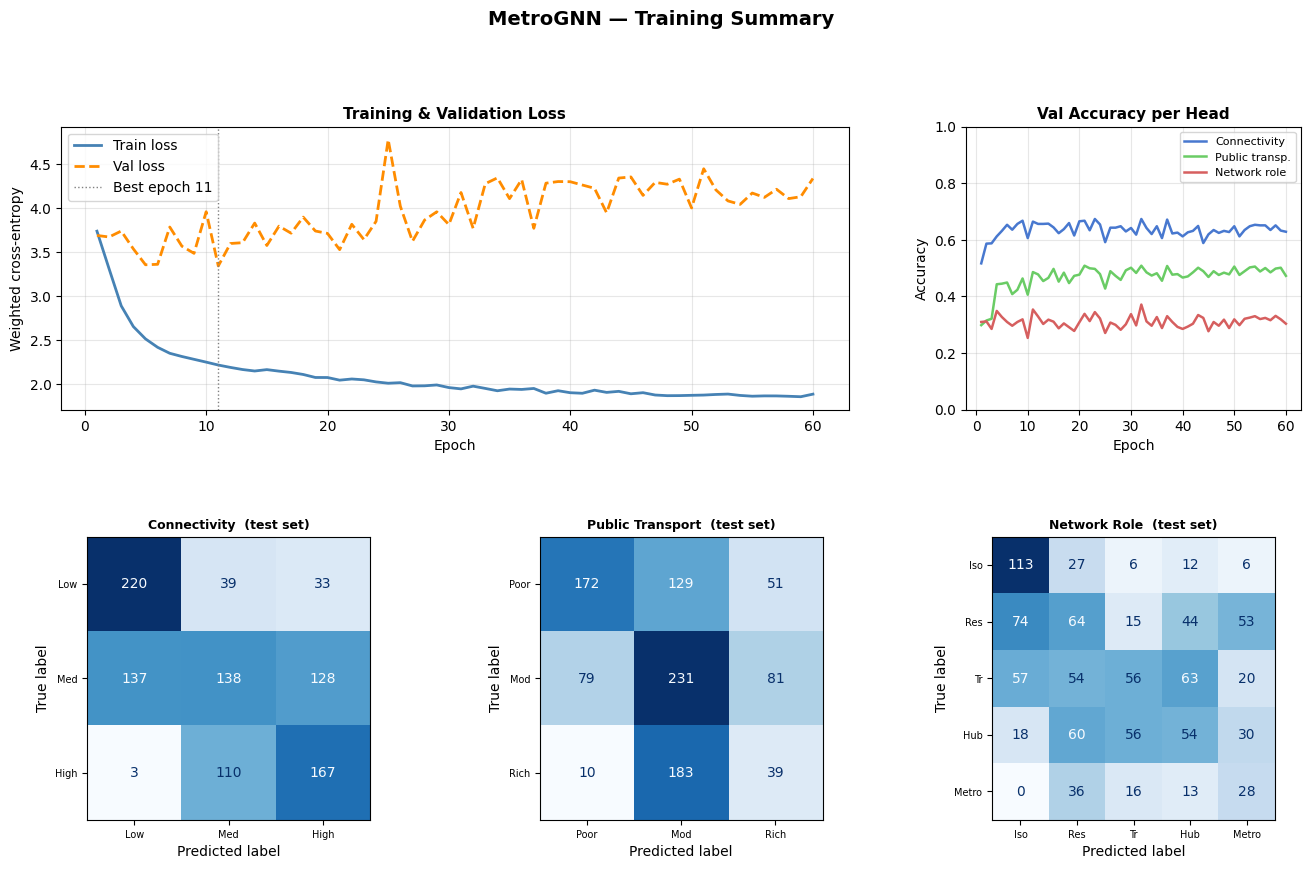

Test accuracy:  connectivity=0.5385  public_transport=0.4533  network_role=0.3231


In [10]:
epochs_x = range(1, len(history['train_loss']) + 1)

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Loss curves ───────────────────────────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, :2])
ax_loss.plot(epochs_x, history['train_loss'],
             color='steelblue', lw=2,  label='Train loss')
ax_loss.plot(epochs_x, history['val_loss'],
             color='darkorange', lw=2, linestyle='--', label='Val loss')
best_ep = int(np.argmin(history['val_loss'])) + 1
ax_loss.axvline(best_ep, color='grey', linestyle=':', lw=1, label=f'Best epoch {best_ep}')
ax_loss.set_title('Training & Validation Loss', fontweight='bold', fontsize=11)
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Weighted cross-entropy')
ax_loss.legend(); ax_loss.grid(alpha=0.3)

# ── Per-head accuracy ─────────────────────────────────────────────────────────
ax_acc = fig.add_subplot(gs[0, 2])
ax_acc.plot(epochs_x, history['val_acc_conn'], lw=1.8,
            color='#4878CF', label='Connectivity')
ax_acc.plot(epochs_x, history['val_acc_pt'],   lw=1.8,
            color='#6ACC65', label='Public transp.')
ax_acc.plot(epochs_x, history['val_acc_role'], lw=1.8,
            color='#D65F5F', label='Network role')
ax_acc.set_title('Val Accuracy per Head', fontweight='bold', fontsize=11)
ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
ax_acc.set_ylim(0, 1); ax_acc.legend(fontsize=8); ax_acc.grid(alpha=0.3)

# ── Confusion matrices on test set ────────────────────────────────────────────
pred_dict = {'conn': [], 'pt': [], 'role': []}
true_dict = {'conn': [], 'pt': [], 'role': []}
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        out   = model(batch.x, batch.edge_index, batch.batch)
        pred_dict['conn'].extend(out['conn_logits'].argmax(1).cpu().tolist())
        true_dict['conn'].extend(batch.y_conn.cpu().tolist())
        pred_dict['pt'].extend(out['pt_logits'].argmax(1).cpu().tolist())
        true_dict['pt'].extend(batch.y_pt.cpu().tolist())
        pred_dict['role'].extend(out['role_logits'].argmax(1).cpu().tolist())
        true_dict['role'].extend(batch.y_role.cpu().tolist())

cm_specs = [
    ('conn', 'Connectivity',     ['Low', 'Med', 'High']),
    ('pt',   'Public Transport', ['Poor', 'Mod', 'Rich']),
    ('role', 'Network Role',     ['Iso', 'Res', 'Tr', 'Hub', 'Metro']),
]
for col, (key, title, labels) in enumerate(cm_specs):
    cm   = confusion_matrix(true_dict[key], pred_dict[key], labels=list(range(len(labels))))
    ax   = fig.add_subplot(gs[1, col])
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}  (test set)', fontweight='bold', fontsize=9)
    ax.tick_params(axis='both', labelsize=7)

fig.suptitle("MetroGNN — Training Summary", fontsize=14, fontweight='bold', y=1.01)
plt.savefig(CFG['out_dir'] / 'training_summary.png', dpi=130, bbox_inches='tight')
plt.show()

# Final test metrics
_, tc, tp, tr = evaluate(test_loader)
print(f"Test accuracy:  connectivity={tc:.4f}  public_transport={tp:.4f}  network_role={tr:.4f}")


---
## 4. Inference

User clicks a map point → nearest OSM node → extract same 250m subgraph → run GNN → structured JSON + LLM context.


In [11]:
import osmnx as ox

def infer_location(lat: float, lon: float) -> dict:
    """
    GPS → nearest OSM node → 250m subgraph → GNN → structured output.
    Uses the same spatial index and edge_index built in cell-8.
    """
    nearest_nid = ox.nearest_nodes(G, X=lon, Y=lat)
    ci          = id2idx[nearest_nid]

    local_np  = node_tree.query_radius(node_coords_rad[ci:ci+1],
                                       r=CFG['subgraph_r_m'] / 6_371_000)[0]
    local_idx = torch.tensor(local_np, dtype=torch.long)
    sub_ei, _ = pyg_subgraph(local_idx, edge_index_global,
                              relabel_nodes=True, num_nodes=N_TOTAL)

    sub_x_raw  = X_raw_tensor[local_idx]   # 8 cols raw — evidence
    sub_x_norm = X_norm_tensor[local_idx]  # 7 cols normalized — GNN input

    # Evidence (from raw features)
    major_inters = int((sub_x_raw[:, 1] > 0).sum())
    bus_cnt      = int(sub_x_raw[:, 4].sum())
    lrt_cnt      = int(sub_x_raw[:, 5].sum())
    train_cnt    = int(sub_x_raw[:, 6].sum())
    routes_cnt   = int(sub_x_raw[:, 7].sum())

    # GNN forward (normalized features)
    batch_vec = torch.zeros(len(local_idx), dtype=torch.long)
    model.eval()
    with torch.no_grad():
        out = model(sub_x_norm.to(DEVICE), sub_ei.to(DEVICE), batch_vec.to(DEVICE))

    return {
        'lat': lat, 'lon': lon,
        'nearest_osm_node':       int(nearest_nid),
        'subgraph_nodes':         len(local_idx),
        'connectivity_level':     CONN_LABELS[out['conn_logits'].argmax(1).item()],
        'public_transport_level': PT_LABELS[out['pt_logits'].argmax(1).item()],
        'network_role':           ROLE_LABELS[out['role_logits'].argmax(1).item()],
        'evidence': {
            'major_intersections_count': major_inters,
            'bus_stop_count':            bus_cnt,
            'light_rail_stop_count':     lrt_cnt,
            'train_stop_count':          train_cnt,
            'unique_gtfs_routes_count':  routes_cnt,
        },
    }


def build_llm_context(d: dict) -> str:
    """GNN output → Hebrew prompt block for LLM injection."""
    role_he = {
        'isolated':         'מבודד',
        'residential':      'שכונתי',
        'transit_served':   'משורת תח"צ',
        'local_hub':        'צומת מקומי',
        'metropolitan_hub': 'צומת מטרופוליני',
    }
    ev = d['evidence']
    return (
        f"[GNN — תחבורה]\n"
        f"תפקיד: {role_he.get(d['network_role'], d['network_role'])} | "
        f"קישוריות: {d['connectivity_level']} | "
        f"תח\"צ: {d['public_transport_level']}\n"
        f"צמתים ראשיים: {ev['major_intersections_count']} | "
        f"אוטובוסים: {ev['bus_stop_count']} | "
        f"קל\"ק: {ev['light_rail_stop_count']} | "
        f"רכבת: {ev['train_stop_count']} | "
        f"קווים: {ev['unique_gtfs_routes_count']}"
    )


# ── Test on Tel Aviv landmarks ─────────────────────────────────────────────────
locations = [
    ("Azrieli Center",       32.0743, 34.7925),
    ("Dizengoff Square",     32.0790, 34.7742),
    ("Tel Aviv University",  32.1133, 34.8044),
    ("Jaffa Port",           32.0519, 34.7503),
    ("Rabin Square",         32.0804, 34.7812),
    ("HaHagana Station",     32.0499, 34.7698),
]

print(f"{'Location':<25} {'Role':<20} {'Connectivity':<14} {'PT Level'}")
print("─" * 72)
results = []
for name, lat, lon in locations:
    r = infer_location(lat, lon)
    r['name'] = name
    results.append(r)
    print(f"{name:<25} {r['network_role']:<20} {r['connectivity_level']:<14} "
          f"{r['public_transport_level']}")
    ev = r['evidence']
    print(f"  subgraph={r['subgraph_nodes']} nodes  "
          f"major={ev['major_intersections_count']}  "
          f"bus={ev['bus_stop_count']}  "
          f"routes={ev['unique_gtfs_routes_count']}")
print("─" * 72)

print("\n--- Structured output (Azrieli) ---")
print(json.dumps({k: v for k, v in results[0].items() if k != 'name'},
                 ensure_ascii=False, indent=2))
print("\n--- LLM context block ---")
print(build_llm_context(results[0]))

with open(CFG['out_dir'] / 'inference_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f"\nSaved {len(results)} results → {CFG['out_dir']}/inference_results.json")


Location                  Role                 Connectivity   PT Level
────────────────────────────────────────────────────────────────────────
Azrieli Center            metropolitan_hub     high           rich
  subgraph=39 nodes  major=30  bus=512  routes=34989
Dizengoff Square          transit_served       medium         moderate
  subgraph=32 nodes  major=14  bus=370  routes=1551
Tel Aviv University       transit_served       medium         poor
  subgraph=9 nodes  major=7  bus=95  routes=516
Jaffa Port                residential          low            moderate
  subgraph=23 nodes  major=4  bus=249  routes=322
Rabin Square              metropolitan_hub     high           rich
  subgraph=42 nodes  major=35  bus=756  routes=3142
HaHagana Station          local_hub            high           moderate
  subgraph=34 nodes  major=22  bus=480  routes=1623
────────────────────────────────────────────────────────────────────────

--- Structured output (Azrieli) ---
{
  "lat": 32.0743,
  "lo